# Predizione del Prezzo di Auto usate

**Programmazione di Applicazioni Data Intensive**  
Elaborato finale A.A. 2025/26  
Laurea in Ingegneria e Scienze Informatiche  
DISI - Università di Bologna, Cesena  

Giulia Albertini 

`giulia.albertini3@studio.unibo.it`

## Contesto e Obiettivo

Il mercato delle auto usate è caratterizzato da una forte asimmetria informativa: acquirenti e venditori spesso non hanno gli strumenti per valutare oggettivamente se il prezzo di un veicolo sia equo rispetto alle sue caratteristiche. Questo progetto si propone di costruire un modello predittivo in grado di stimare il prezzo di un'auto usata a partire da variabili descrittive del veicolo (anno, marca, chilometraggio, condizione, ecc.), con l'obiettivo di aiutare un potenziale acquirente a capire se un'auto è sopra o sotto mercato.

## Dataset
- **Fonte:** Kaggle – *Used Cars Dataset* (Craigslist Cars and Trucks)
- **URL:** https://www.kaggle.com/datasets/austinreese/craigslist-carstrucks-data
- **Dimensione:** ~420.000 righe, 26 colonne
- **Variabile target:** `price` (prezzo in dollari, variabile continua → problema di **regressione**)



### Variabili presenti nel dataset
| Colonna | Tipo | Descrizione |
|---|---|---|
| `price` | Numerica | Prezzo dell'auto (TARGET) |
| `year` | Numerica | Anno di immatricolazione |
| `manufacturer` | Categorica | Marca (ford, toyota, ...) |
| `model` | Categorica | Modello specifico |
| `condition` | Categorica ordinale | Condizione (new, like new, excellent, good, fair, salvage) |
| `cylinders` | Categorica | Numero di cilindri |
| `fuel` | Categorica | Tipo di carburante |
| `odometer` | Numerica | Chilometraggio |
| `transmission` | Categorica | Tipo di trasmissione |
| `drive` | Categorica | Trazione (fwd, rwd, 4wd) |
| `type` | Categorica | Tipo veicolo (sedan, SUV, ...) |
| `paint_color` | Categorica | Colore |
| `state` | Categorica | Stato USA |
| `lat`, `long` | Numerica | Coordinate geografiche |
| `posting_date` | Data | Data dell'annuncio |
| `description` | Testo | Descrizione testuale dell'annuncio |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tempfile

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder, OrdinalEncoder, LabelEncoder, FunctionTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor, export_text
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from shutil import rmtree
from sklearnex import patch_sklearn

patch_sklearn()
from joblib import Memory

Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


### Caricamento del dataset
Il dataset viene caricato tramite la libreria pandas.  
Successivamente vengono visualizzate le prime righe del dataset per comprendere la struttura generale dei dati.

In [2]:
df = pd.read_csv("vehicles.csv")

In [3]:
df.head()

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


Dalle prime righe del dataset si osserva la presenza di numerose informazioni relative agli annunci, tra cui:

- prezzo del veicolo,
- area geografica,
- anno di produzione,
- marca,
- modello,
- carburante,
- chilometraggio.

Si nota inoltre la presenza di numerosi valori mancanti (`NaN`) in diverse colonne, aspetto che richiederà una fase di pulizia e preprocessing dei dati.

### Dimensioni del dataset

Viene analizzato il numero di righe e colonne presenti nel dataset.

In [4]:
df.shape

(426880, 26)

Il dataset contiene:

- 426.880 righe
- 26 colonne

Si tratta quindi di un dataset di dimensioni elevate, adatto ad applicazioni di machine learning e analisi data intensive.

### Analisi della struttura del dataset

La funzione `info()` permette di osservare:
- tipo delle variabili,
- numero di valori non nulli,
- presenza di dati mancanti.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334022 non-null  object 
 18  pain

Il dataset contiene sia variabili numeriche che categoriche.

Le principali variabili numeriche sono:
- `price`
- `year`
- `odometer`
- `lat`
- `long`

Molte colonne categoriche presentano valori mancanti, in particolare:
- `size`
- `condition`
- `cylinders`
- `drive`
- `paint_color`

La colonna `county` contiene esclusivamente valori nulli e potrà quindi essere rimossa nelle fasi successive.

### Statistiche descrittive delle variabili numeriche

Vengono calcolate statistiche descrittive per le variabili numeriche del dataset.

In [6]:
df.describe()

,id,price,year,odometer,county,lat,long
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05,0.0,420331.000000,420331.000000
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04,NaN,38.493940,-94.748599
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05,NaN,5.841533,18.365462
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00,NaN,-84.122245,-159.827728
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04,NaN,34.601900,-111.939847
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04,NaN,39.150100,-88.432600
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05,NaN,42.398900,-80.832039
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07,NaN,82.390818,173.885502


Dall’analisi statistica emergono alcune anomalie nei dati:

- il prezzo minimo è pari a 0, valore non realistico per un’automobile;
- il prezzo massimo supera i 3 miliardi di dollari, indicando la presenza di outlier;
- il chilometraggio massimo raggiunge 10 milioni di miglia, anch’esso probabilmente anomalo;
- sono presenti automobili con anno di produzione pari al 1900.

Queste osservazioni indicano la necessità di una fase di pulizia dei dati per rimuovere valori non realistici che potrebbero compromettere le performance dei modelli predittivi.

### Analisi dei valori mancanti

Viene calcolata la percentuale di valori mancanti per ciascuna colonna del dataset.

In [7]:
#Esploro il dataset
missing = df.isnull().mean() * 100

missing.sort_values(ascending=False)

county          100.000000
size             71.767476
cylinders        41.622470
condition        40.785232
VIN              37.725356
drive            30.586347
paint_color      30.501078
type             21.752717
manufacturer      4.133714
title_status      1.930753
lat               1.534155
long              1.534155
model             1.236179
odometer          1.030735
fuel              0.705819
transmission      0.598763
year              0.282281
description       0.016398
image_url         0.015930
posting_date      0.015930
url               0.000000
price             0.000000
state             0.000000
region_url        0.000000
region            0.000000
id                0.000000
dtype: float64

L’analisi dei valori mancanti mostra che alcune colonne presentano una quantità elevata di dati assenti.

In particolare:
- `county` contiene il 100% di valori nulli;
- `size` presenta oltre il 70% di valori mancanti;
- `condition` e `cylinders` hanno oltre il 40% di dati mancanti.

Alcune colonne con una quantità eccessiva di valori nulli potrebbero essere eliminate, mentre altre verranno gestite tramite tecniche di imputazione o encoding durante il preprocessing.

# Data cleaning

In questa fase viene eseguita una pulizia del dataset per rimuovere informazioni non utili e valori anomali che potrebbero influenzare negativamente le performance dei modelli di machine learning.
Per preservare il dataset originale, viene creata una copia su cui eseguire le operazioni di pulizia e preprocessing.

In particolare:

- vengono eliminate **colonne non informative come identificatori, URL e colonne con un numero eccessivo di valori mancanti**;
- vengono rimossi **annunci con prezzi non realistici**;
- vengono filtrati veicoli con **anno di produzione o chilometraggio anomali**.

Inoltre, dal campo testuale `description` vengono estratte alcune feature binarie utili a identificare informazioni potenzialmente rilevanti per il prezzo del veicolo, come la presenza di riferimenti a incidenti, certificazioni o sostituzione degli pneumatici.

Queste operazioni consentono di ottenere un dataset più coerente e adatto alle successive fasi di analisi e modellazione.

In [8]:
cols_to_drop = [
    'id',          
    'url',         
    'region_url',  
    'image_url',   
    'VIN',         
    'county',      
    'description', 
    'region',      
]


df['desc_len'] = df['description'].fillna('').apply(len)
df['desc_has_accident'] = df['description'].fillna('').str.lower().str.contains('accident|damage').astype(int)
df['desc_has_certified'] = df['description'].fillna('').str.lower().str.contains('certified|warranty').astype(int)
df['desc_has_new_tires'] = df['description'].fillna('').str.lower().str.contains('new tires|new tire').astype(int)

df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)
print(f'Dimensione dopo rimozione colonne: {df.shape}')

Dimensione dopo rimozione colonne: (426880, 22)


## Pulizia delle variabili target: prezzo, anno e chilometraggio

Le variabili `price`, `year` e `odometer` presentano numerosi valori anomali e non realistici che potrebbero compromettere l’addestramento dei modelli di regressione.

In particolare:

- la colonna `price` contiene valori pari a 0, prezzi estremamente bassi o valori eccessivamente elevati dovuti ad annunci errati o incompleti;
- la colonna `year` include veicoli con anni di produzione non coerenti con il mercato automobilistico moderno;
- la colonna `odometer` presenta chilometraggi nulli o eccessivamente elevati, probabilmente causati da errori di inserimento.

Per migliorare la qualità del dataset vengono quindi mantenuti solamente annunci con:
- prezzo compreso tra 500 e 150.000 dollari;
- anno di produzione compreso tra 1980 e 2025;
- chilometraggio positivo e inferiore a 500.000 miglia.
La colonna price contiene valori anomali (0 , prezzi irrisori, prezzi assurdi > 200k $) che corrispondono ad annunci mal compilati o con prezzo da trattare. Vengono eliminati per non distorcere i modelli.

In [9]:
df = df[(df['price'] >= 500) & (df['price'] <= 150_000)]

current_year = 2025
df = df[(df['year'] >= 1980) & (df['year'] <= current_year)]

df = df[(df['odometer'] >= 0) & (df['odometer'] <= 500_000)]

print(f'Dimensione dopo pulizia outlier: {df.shape}')

Dimensione dopo pulizia outlier: (372504, 22)


# Analisi Esplorativa dei Dati (EDA)

### Verifica del Dataset pulito

Vengono nuovamente analizzate le statistiche descrittive del dataset dopo la fase di pulizia.

In [10]:
df.describe()

,price,year,odometer,lat,long,desc_len,desc_has_accident,desc_has_certified,desc_has_new_tires
count,372504.000000,372504.000000,372504.000000,369133.000000,369133.000000,372504.000000,372504.000000,372504.000000,372504.000000
mean,19235.439893,2011.996964,93847.831366,38.524482,-94.223763,2851.747654,0.265111,0.233898,0.054077
std,14697.258489,6.402710,64250.864355,5.853961,18.084915,2799.504446,0.441393,0.423309,0.226170
min,500.000000,1980.000000,0.000000,-81.838232,-159.719900,0.000000,0.000000,0.000000,0.000000
25%,7800.000000,2008.000000,39058.000000,34.720000,-110.878886,541.000000,0.000000,0.000000,0.000000
50%,15920.000000,2013.000000,88809.000000,39.254962,-87.947800,2339.000000,0.000000,0.000000,0.000000
75%,27990.000000,2017.000000,136875.000000,42.368800,-80.801896,4297.000000,1.000000,0.000000,0.000000
max,150000.000000,2022.000000,500000.000000,82.252826,173.885502,28832.000000,1.000000,1.000000,1.000000


## Distribuzione del prezzo delle auto (target)

La distribuzione del prezzo rappresenta una delle informazioni più importanti del dataset.
La distribuzione del prezzo è fortemente asimmetrica a destra (right-skewed): la maggior parte delle auto ha prezzi relativamente bassi, ma esistono auto di lusso con prezzi molto elevati. Questo giustifica l'applicazione di una trasformazione logaritmica prima dell'addestramento.

L’analisi consente quindi di osservare:
- la presenza di valori estremi,
- eventuali asimmetrie nella distribuzione,
- la necessità di applicare trasformazioni al target.

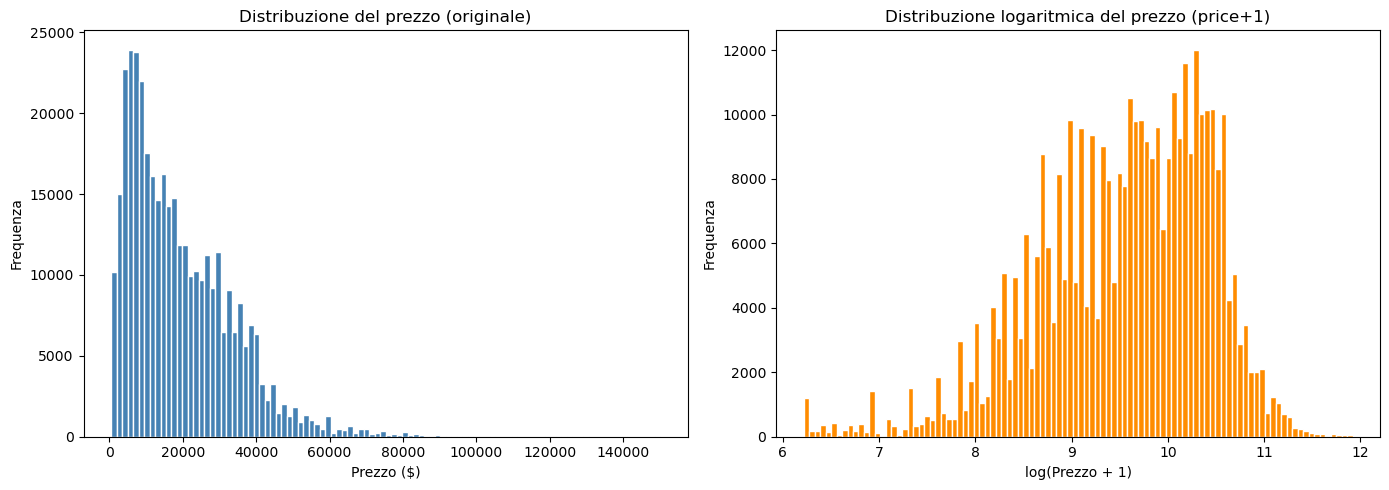

Skewness originale: 1.49
Skewness log-trasformata: -0.73


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuzione originale
axes[0].hist(df['price'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuzione del prezzo (originale)')
axes[0].set_xlabel('Prezzo ($)')
axes[0].set_ylabel('Frequenza')

# Distribuzione log-trasformata
axes[1].hist(np.log1p(df['price']), bins=100, color='darkorange', edgecolor='white')
axes[1].set_title('Distribuzione logaritmica del prezzo (price+1)')
axes[1].set_xlabel('log(Prezzo + 1)')
axes[1].set_ylabel('Frequenza')

plt.tight_layout()
plt.show()

print(f'Skewness originale: {df["price"].skew():.2f}')
print(f'Skewness log-trasformata: {np.log1p(df["price"]).skew():.2f}')

La trasformazione logaritmica riduce significativamente l’asimmetria, rendendo la distribuzione più simile a una normale e migliorando le performance dei modelli lineari che assumono errori gaussiani.

## Analisi variabili categoriche


Le variabili categoriche rappresentano una componente fondamentale del dataset poiché molte caratteristiche qualitative del veicolo possono influenzarne significativamente il prezzo.

In questa sezione vengono analizzate:
- le marche più presenti negli annunci;
- il prezzo mediano associato ai diversi produttori;
- la distribuzione di condizione, carburante e trasmissione.

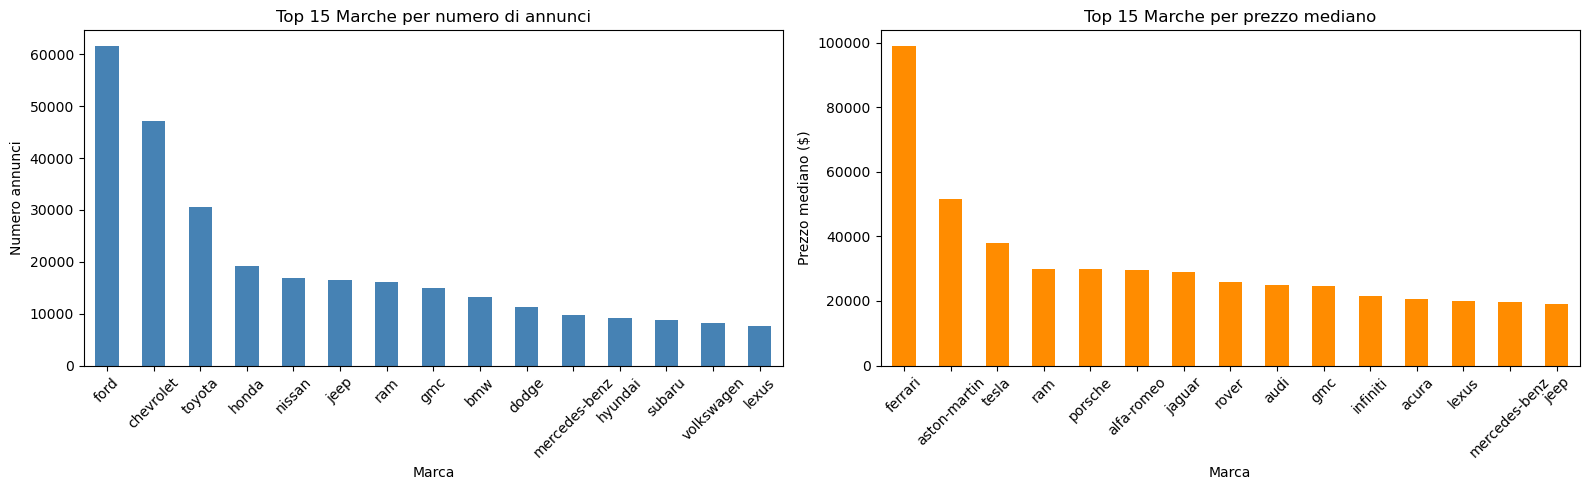

In [12]:
top_manufacturers = df['manufacturer'].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top_manufacturers.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 Marche per numero di annunci')
axes[0].set_xlabel('Marca')
axes[0].set_ylabel('Numero annunci')
axes[0].tick_params(axis='x', rotation=45)

# Prezzo mediano per marca
median_price_by_brand = df.groupby('manufacturer')['price'].median().sort_values(ascending=False).head(15)
median_price_by_brand.plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Top 15 Marche per prezzo mediano')
axes[1].set_xlabel('Marca')
axes[1].set_ylabel('Prezzo mediano ($)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

L’analisi mostra che alcuni produttori, come Ford, Chevrolet e Toyota, risultano particolarmente frequenti nel dataset, riflettendo la loro ampia diffusione nel mercato delle auto usate statunitense.

Osservando invece il prezzo mediano, emergono differenze significative tra i vari marchi: produttori premium o di lusso tendono ad avere prezzi mediamente più elevati rispetto ai marchi generalisti.

Questo suggerisce che la variabile `manufacturer` possa avere un forte impatto nella predizione del prezzo del veicolo.

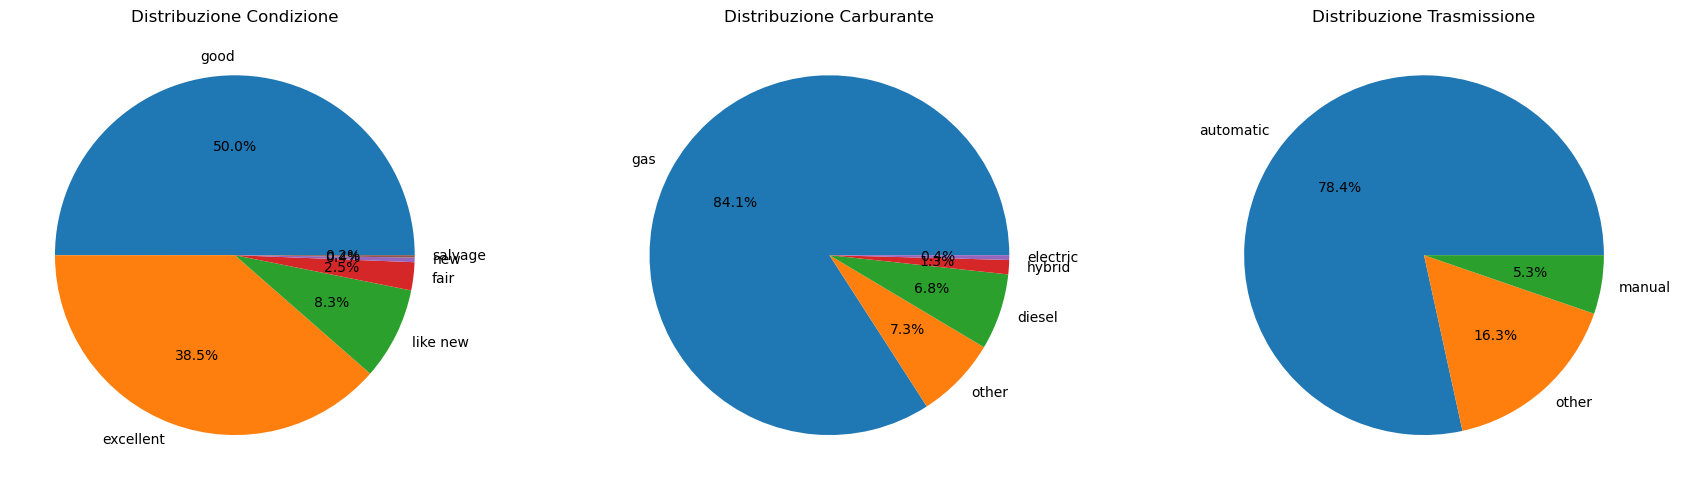

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Condition
df['condition'].value_counts().plot(kind='pie', ax=axes[0], autopct='%1.1f%%')
axes[0].set_title('Distribuzione Condizione')
axes[0].set_ylabel('')

# Fuel
df['fuel'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%')
axes[1].set_title('Distribuzione Carburante')
axes[1].set_ylabel('')

# Transmission
df['transmission'].value_counts().plot(kind='pie', ax=axes[2], autopct='%1.1f%%')
axes[2].set_title('Distribuzione Trasmissione')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

La maggior parte dei veicoli presenti nel dataset risulta in condizioni `good` o `excellent`, mentre le auto in condizioni peggiori rappresentano una percentuale ridotta.

Per quanto riguarda il carburante, predominano i veicoli a benzina, coerentemente con il mercato automobilistico statunitense.

La trasmissione automatica risulta nettamente più diffusa rispetto a quella manuale, evidenziando una forte prevalenza di veicoli automatici negli annunci analizzati.

### Relazione tra condizione del veicolo e prezzo

Viene analizzato il rapporto tra la condizione dichiarata del veicolo e il relativo prezzo di vendita.

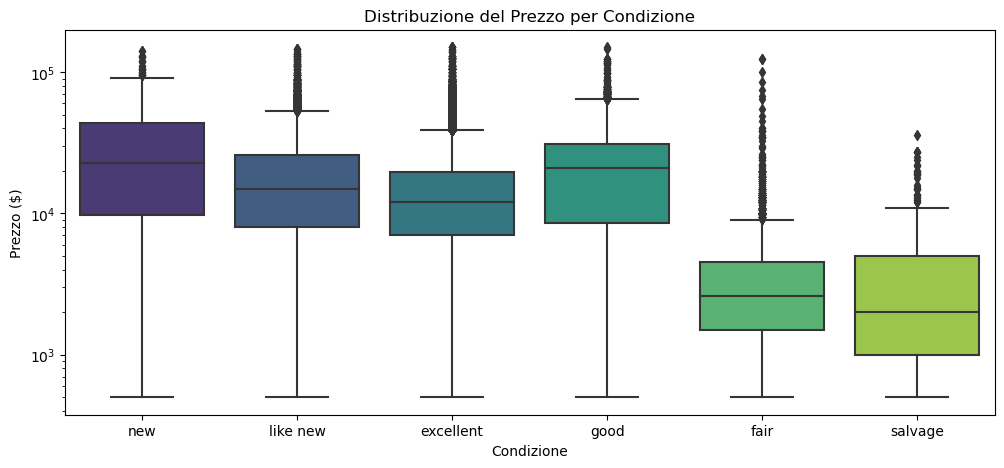

In [14]:
order = ['new', 'like new', 'excellent', 'good', 'fair', 'salvage']
order = [o for o in order if o in df['condition'].unique()]

plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='condition', y='price', order=order, palette='viridis')
plt.title('Distribuzione del Prezzo per Condizione')
plt.xlabel('Condizione')
plt.ylabel('Prezzo ($)')
plt.yscale('log')
plt.show()

Il boxplot evidenzia una relazione chiara tra condizione del veicolo e prezzo.

I veicoli classificati come `new` o `like new` presentano generalmente prezzi più elevati, mentre le auto in condizioni `fair` o `salvage` risultano significativamente meno costose.

La presenza di una certa variabilità all’interno delle categorie suggerisce comunque che il prezzo dipenda anche da ulteriori fattori, come anno di produzione, marca e chilometraggio.

## Analisi variabili numeriche e correlazioni

Per comprendere meglio i fattori che influenzano il prezzo delle auto usate vengono analizzate le relazioni tra alcune delle principali variabili numeriche del dataset.

In particolare, vengono osservati:
- il rapporto tra anno di produzione, chilometraggio e prezzo;
- la distribuzione geografica degli annunci;
- le correlazioni tra le variabili numeriche.

#### Relazione tra anno di produzione, chilometraggio e prezzo

I grafici mostrano due delle relazioni più rilevanti presenti nel dataset rispetto al prezzo delle auto usate.

Nel primo grafico si osserva una correlazione positiva tra anno di produzione e prezzo: i veicoli più recenti tendono infatti ad avere un valore economico maggiore rispetto ai modelli più datati.

Nel secondo grafico emerge invece una correlazione negativa tra chilometraggio e prezzo. All’aumentare delle miglia percorse il valore del veicolo tende generalmente a diminuire, coerentemente con il maggiore livello di usura del mezzo.

In entrambi i casi è presente una certa dispersione dei dati, segno che il prezzo dipende anche da ulteriori fattori come marca, condizioni del veicolo, carburante e tipologia di trasmissione.

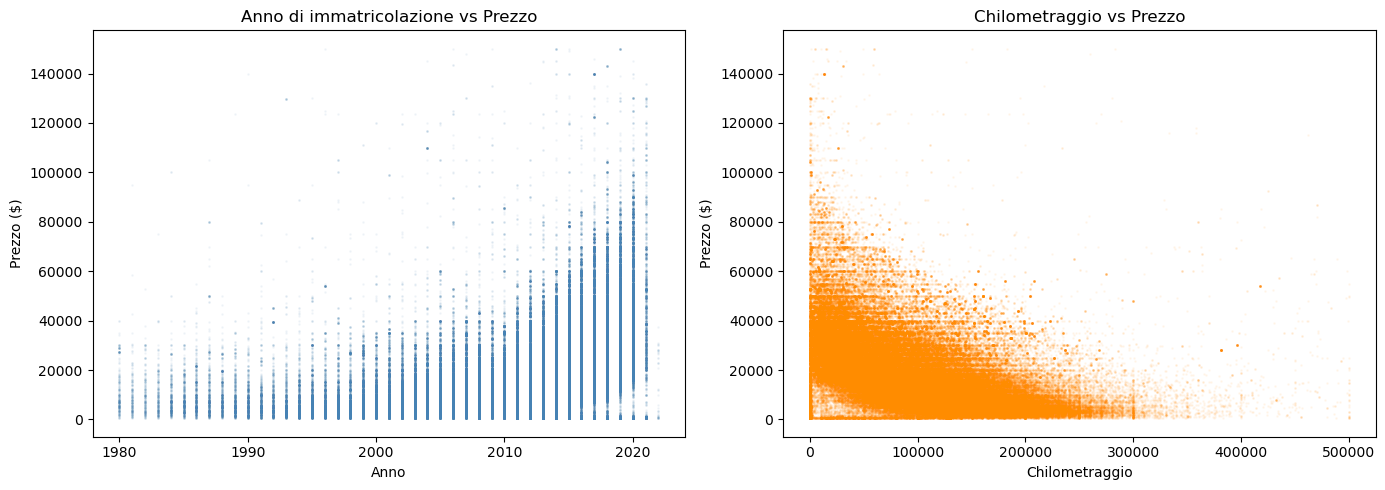

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['year'], df['price'], alpha=0.05, s=1, color='steelblue')
axes[0].set_title('Anno di immatricolazione vs Prezzo')
axes[0].set_xlabel('Anno')
axes[0].set_ylabel('Prezzo ($)')

axes[1].scatter(df['odometer'], df['price'], alpha=0.05, s=1, color='darkorange')
axes[1].set_title('Chilometraggio vs Prezzo')
axes[1].set_xlabel('Chilometraggio')
axes[1].set_ylabel('Prezzo ($)')

plt.tight_layout()
plt.show()

#### Distribuzione geografica degli annunci

La mappa geografica mostra la distribuzione degli annunci di auto usate sul territorio statunitense.

Ogni punto rappresenta un annuncio, mentre il colore indica il prezzo del veicolo in scala logaritmica. Le aree con maggiore concentrazione di annunci coincidono principalmente con le regioni più densamente popolate degli Stati Uniti.

La visualizzazione suggerisce inoltre la presenza di differenze geografiche nei prezzi medi delle automobili, aspetto che potrebbe influenzare le performance dei modelli predittivi.

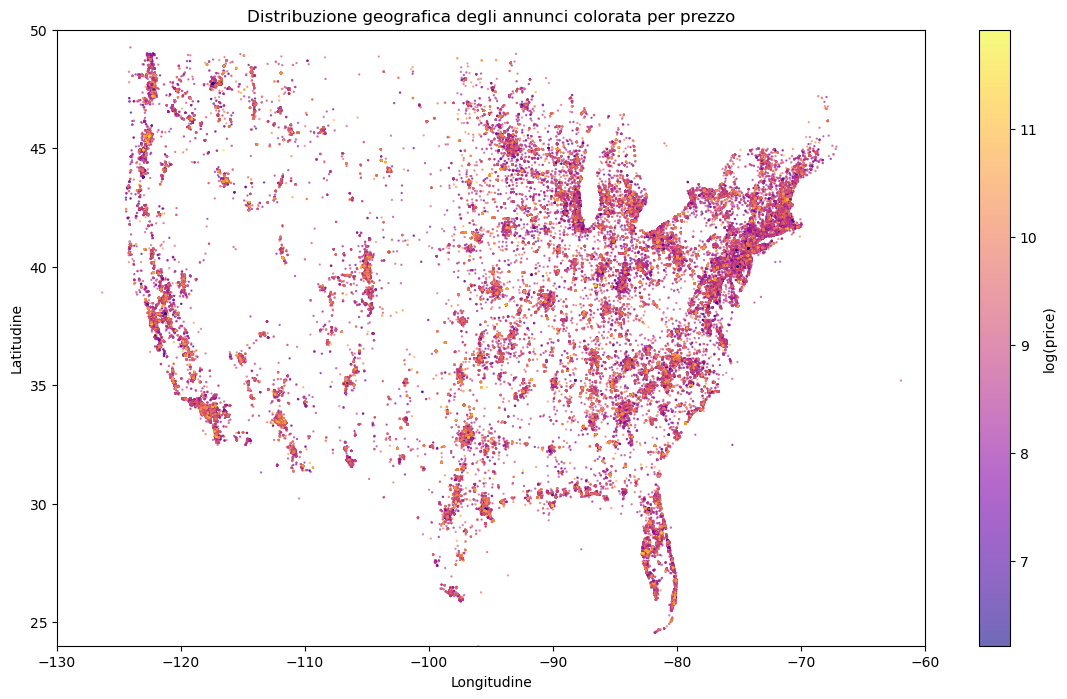

In [16]:
plt.figure(figsize=(14, 8))
scatter = plt.scatter(
    df['long'].dropna(), 
    df.loc[df['long'].notna(), 'lat'],
    c=np.log1p(df.loc[df['long'].notna(), 'price']), s=0.5, alpha=0.6, cmap='plasma'
)
plt.colorbar(scatter, label='log(price)')
plt.xlim(-130, -60)
plt.ylim(24, 50)
plt.title('Distribuzione geografica degli annunci colorata per prezzo')
plt.xlabel('Longitudine')
plt.ylabel('Latitudine')
plt.show()

#### Analisi delle correlazioni

La matrice di correlazione permette di osservare l’intensità delle relazioni lineari tra le variabili numeriche del dataset.

Le correlazioni più rilevanti rispetto al prezzo risultano essere:
- una correlazione positiva con l’anno di produzione (`year`);
- una correlazione negativa con il chilometraggio (`odometer`).

Questi risultati confermano che i veicoli più recenti tendono ad avere un valore economico maggiore, mentre un elevato chilometraggio influisce negativamente sul prezzo.

La heatmap risulta utile anche per individuare eventuali relazioni ridondanti tra variabili, informazione importante nelle successive fasi di modellazione.

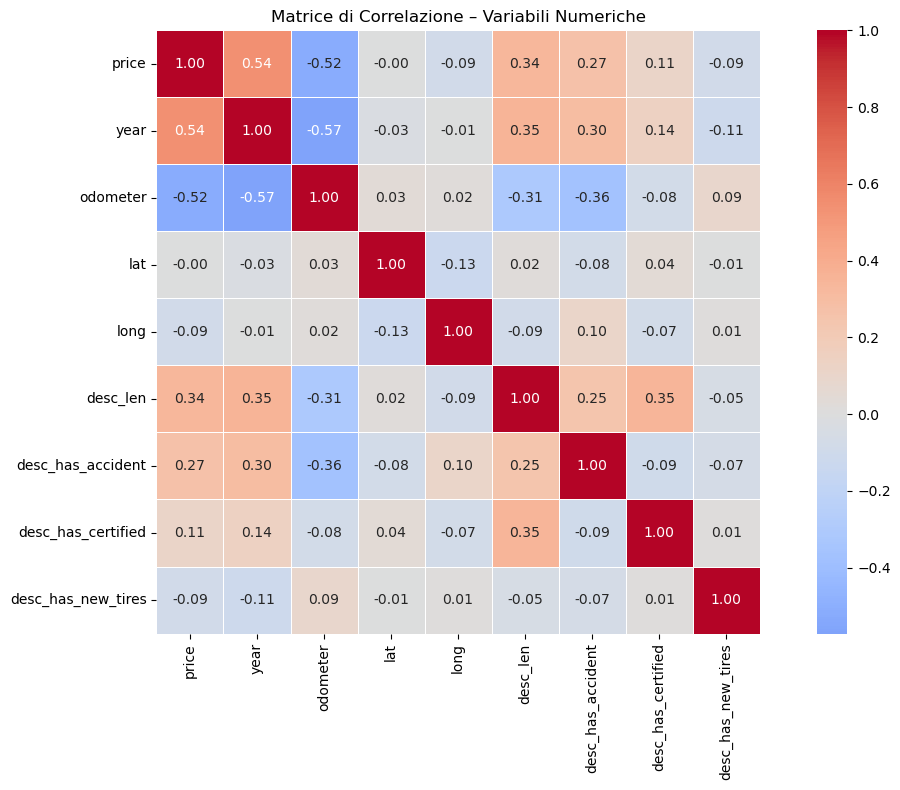


Correlazione con price:
price                 1.000000
year                  0.540272
desc_len              0.341483
desc_has_accident     0.267853
desc_has_certified    0.114565
lat                  -0.004632
desc_has_new_tires   -0.091631
long                 -0.091761
odometer             -0.519438
Name: price, dtype: float64


In [17]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Matrice di Correlazione – Variabili Numeriche')
plt.tight_layout()
plt.show()

# Correlazioni con price ordinate
print('\nCorrelazione con price:')
print(corr_matrix['price'].sort_values(ascending=False))

## Feature Engineering

In questa fase, il dataset originale viene arricchito attraverso la generazione di nuove variabili (features) derivate, con l'obiettivo di trasformare i dati grezzi in segnali più chiari e interpretabili per gli algoritmi di machine learning.

L'ottimizzazione del set informativo è fondamentale per migliorare la capacità predittiva del modello e ridurre l'errore nelle stime del prezzo. In particolare, sono stati implementati i seguenti interventi:

In particolare vengono create variabili per:

- analisi dell'anzianità
- scomposizione etmporale
- geospatial proxy
- codifica delle Condizioni (Ordinal Encoding)
- gestione della Cardinalità

####  Età dell'auto al momento dell'annuncio

In [18]:
df['car_age'] = 2025 - df['year']

####  Estrazione campi temporali dalla data dell'annuncio

Per catturare eventuali dinamiche stagionali o trend legati al momento della pubblicazione, la data dell'annuncio è stata scomposta in tre componenti granulari: mese, anno e giorno della settimana. Questa scomposizione permette all'algoritmo di identificare se il prezzo o la frequenza delle vendite variano, ad esempio, durante i fine settimana o in determinati periodi dell'anno.

In [19]:
df['posting_date'] = pd.to_datetime(df['posting_date'], utc=True, errors='coerce')
df['posting_month'] = df['posting_date'].dt.month
df['posting_dayofweek'] = df['posting_date'].dt.dayofweek
df['posting_year'] = df['posting_date'].dt.year

####  Distanza dal centro geografico (proxy per zona rurale/urbana) e centro approssimativo degli USA

Data la natura geografica del dataset, è stata introdotta una metrica di prossimità spaziale. Calcolando la distanza tra le coordinate GPS dell'annuncio e il centro geografico degli Stati Uniti, abbiamo creato una variabile (dist_from_center) che funge da proxy per la localizzazione. Questo aiuta il modello a distinguere tra mercati potenzialmente diversi, come quelli delle zone costiere rispetto alle zone rurali centrali

In [20]:
center_lat, center_lon = 39.5, -98.35
df['dist_from_center'] = np.sqrt(
    (df['lat'] - center_lat)**2 + (df['long'] - center_lon)**2
)

#### Codifica ordinale per condition

La variabile qualitativa condition è stata trasformata in una scala numerica ordinale. A differenza di una codifica nominale, l'Ordinal Encoding preserva la gerarchia intrinseca dello stato del veicolo (da salvage a new), permettendo al modello di percepire che una vettura in condizioni 'eccellenti' ha un valore superiore rispetto a una in condizioni 'buone'

In [21]:
condition_map = {'salvage': 0, 'fair': 1, 'good': 2, 'excellent': 3, 'like new': 4, 'new': 5}
df['condition_encoded'] = df['condition'].map(condition_map)

#### Gestione della Cardinalità (Modelli Auto)

Per evitare problemi di dimensionalità dovuto alla presenza di migliaia di nomi di modelli unici, è stata effettuata una riduzione della cardinalità. Sono stati mantenuti i 50 modelli più frequenti, mentre tutte le restanti osservazioni sono state raggruppate sotto la categoria generica other. Questa tecnica semplifica lo spazio delle feature e riduce il rischio di overfitting.

In [22]:
# Riduzione cardinalità di 'model': mantieni top-50 modelli, resto = 'other'
top_models = df['model'].value_counts().head(50).index
df['model_clean'] = df['model'].apply(lambda x: x if x in top_models else 'other')

#### Trasformazione logaritmica del target

La variabile target price è stata sottoposta a una trasformazione logaritmica ($\log(1+x)$). Questa operazione è fondamentale per normalizzare una distribuzione spesso asimmetrica (skewed) e ridurre l'impatto dei valori anomali (outliers). In questo modo, il modello minimizza l'errore relativo anziché quello assoluto, migliorando la capacità predittiva sui segmenti di prezzo più comuni.

In [23]:
df['log_price'] = np.log1p(df['price'])

# Preparazione dei Dati per il Training

Le feature sono suddivise in due gruppi in base alla loro natura:
- **Numeriche** (`features_num`): vengono standardizzate con `StandardScaler`, che sottrae la media e divide per la deviazione standard, portando tutte le variabili sulla stessa scala. Questo è necessario per modelli sensibili alla magnitudine delle feature come Ridge.
- **Categoriche** (`features_cat`): vengono codificate con `OneHotEncoder`, che trasforma ogni categoria in una colonna binaria. Il parametro `drop='first'` evita la multicollinearità eliminando una categoria ridondante per variabile; `handle_unknown='ignore'` gestisce eventuali categorie non viste in fase di training.

Il `ColumnTransformer` applica le due trasformazioni in parallelo e concatena i risultati in un'unica matrice di feature.

In [24]:
features_num = [
    'year', 'car_age', 'odometer', 
    'lat', 'long', 'dist_from_center',
    'posting_month', 'posting_dayofweek',
    'condition_encoded',
    'desc_len', 'desc_has_accident', 'desc_has_certified', 'desc_has_new_tires'
]

features_cat = [
    'manufacturer', 'fuel', 'transmission', 'drive', 
    'type', 'paint_color', 'state', 'cylinders', 'title_status'
]

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), features_num),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first', dtype=int), features_cat),
], remainder='drop')


A partire da `df_clean` viene costruita la matrice `X_raw` selezionando solo le colonne rilevanti. La variabile target è `log_price` (logaritmo del prezzo), che era stata calcolata in precedenza per ridurre l'asimmetria della distribuzione e stabilizzare la varianza.

Il dataset viene suddiviso in training set (80%) e test set (20%) con `random_state=42` per garantire la riproducibilità. Viene mantenuto anche `y_orig` (il prezzo originale in dollari) per calcolare le metriche di errore in scala reale dopo la predizione.

In [25]:
df_clean = df.dropna().copy()

X_raw = df_clean[features_num + features_cat]
y     = df_clean['log_price'].values
y_orig = df_clean['price'].values

X_train_raw, X_test_raw, y_train, y_test, y_orig_train, y_orig_test = train_test_split(
    X_raw, y, y_orig, test_size=0.2, random_state=42
)

Vengono definite due strategie di cross-validation con k-fold:
- **5-fold**: divide il training set in 5 parti, addestra su 4 e valida sulla quinta, ripetendo il processo 5 volte. Offre un buon compromesso tra varianza della stima e costo computazionale.
- **7-fold**: utilizza 7 fold, riducendo ulteriormente il bias della stima a scapito di un tempo di esecuzione maggiore.

Il parametro `shuffle=True` mescola i dati prima di creare i fold, evitando che eventuali ordinamenti nel dataset influenzino i risultati.

Confrontare i due schemi permette di verificare la stabilità delle performance dei modelli al variare della strategia di validazione.

In [26]:
k_fold_5 = KFold(n_splits=5, shuffle=True, random_state=42)
k_fold_7 = KFold(n_splits=7, shuffle=True, random_state=42)

# Costruzione dei modelli

Per la valutazione di ciascun modello vengono applicati due approcci di suddivisione dei dati:
- **Hold-Out**: i dati vengono divisi staticamente in training (80%) e test (20%). Permette una valutazione rapida.
- **K-Fold Cross Validation**: il dataset viene suddiviso in K sottoinsiemi, usati alternativamente come training e validation set. Produce una stima più robusta delle performance, a scapito di un maggiore costo computazionale.

Per ogni modello viene riportata la metrica $R^2$ calcolata sia sul test set (Hold-Out) che come media dei fold (K-Fold). Vengono inoltre calcolate RMSE e MAE in scala originale (dollari), ottenute applicando l'inversa del logaritmo alle predizioni.

In [27]:
def evaluate_pipeline(pipeline, X_tr, X_te, y_tr, y_te, y_orig_te, name='Model'):
    pipeline.fit(X_tr, y_tr)
    y_pred_log  = pipeline.predict(X_te)
    y_pred_orig = np.expm1(y_pred_log)
    return {
        'Model':    name,
        'R² (log)': pipeline.score(X_te, y_te),
        'RMSE ($)': np.sqrt(mean_squared_error(y_orig_te, y_pred_orig)),
        'MAE ($)':  mean_absolute_error(y_orig_te, y_pred_orig),
        'MAPE (%)': np.mean(np.abs((y_orig_te - y_pred_orig) / y_orig_te)) * 100,
    }

results_list   = []
trained_models = {}

In [28]:
def plot_predictions(pipeline, X_test, y_orig_test, name='Model'):
    y_pred_orig = np.expm1(pipeline.predict(X_test))
    errors = y_orig_test - y_pred_orig
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Predetto vs Reale
    axes[0].scatter(y_orig_test, y_pred_orig, alpha=0.05, s=1, color='steelblue')
    lims = [0, min(y_orig_test.max(), y_pred_orig.max())]
    axes[0].plot(lims, lims, 'r--', linewidth=1)
    axes[0].set_title(f'{name} – Predetto vs Reale')
    axes[0].set_xlabel('Prezzo reale ($)')
    axes[0].set_ylabel('Prezzo predetto ($)')
    
    # Distribuzione errori
    axes[1].hist(errors, bins=100, color='darkorange', edgecolor='white')
    axes[1].axvline(0, color='red', linestyle='--')
    axes[1].set_title(f'{name} – Distribuzione errori ($ reali)')
    axes[1].set_xlabel('Errore ($)')
    axes[1].set_ylabel('Frequenza')
    
    plt.tight_layout()
    plt.show()

## Modello di regressione lineare

Linear Reg – R²: 0.723 | RMSE: $6,435 | MAE: $3,632


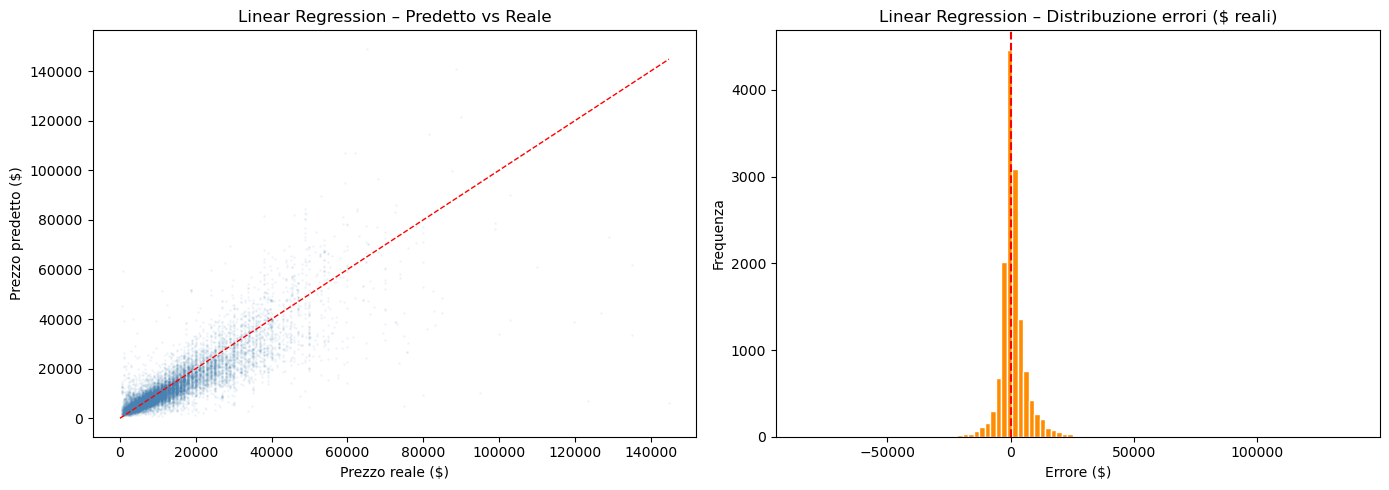

CV-5 Linear Reg – R² medio: 0.723 ± 0.005
CV-7 Linear Reg – R² medio: 0.724 ± 0.005


In [29]:
lr_pipe = Pipeline([
    ('preproc', preprocessor),
    ('regr',    LinearRegression())
])
lr_pipe.fit(X_train_raw, y_train)

res = evaluate_pipeline(lr_pipe, X_train_raw, X_test_raw, y_train, y_test, y_orig_test, 'Linear Regression')
results_list.append(res)
trained_models['LinearRegression'] = lr_pipe
print(f"Linear Reg – R²: {res['R² (log)']:.3f} | RMSE: ${res['RMSE ($)']:,.0f} | MAE: ${res['MAE ($)']:,.0f}")
plot_predictions(lr_pipe, X_test_raw, y_orig_test, 'Linear Regression')

# Analisi coefficienti
lr_features = lr_pipe[:-1].get_feature_names_out()
lr_coef     = lr_pipe.named_steps['regr'].coef_

cv5_lr = cross_validate(lr_pipe, X_raw, y, cv=k_fold_5, scoring='r2')
print(f"CV-5 Linear Reg – R² medio: {cv5_lr['test_score'].mean():.3f} ± {cv5_lr['test_score'].std():.3f}")

cv7_lr = cross_validate(lr_pipe, X_raw, y, cv=k_fold_7, scoring='r2')
print(f"CV-7 Linear Reg – R² medio: {cv7_lr['test_score'].mean():.3f} ± {cv7_lr['test_score'].std():.3f}")

### Regressione lineare + PCA

In [30]:
lr_pca_pipe = Pipeline([
    ('preproc', preprocessor),
    ('to_dense', FunctionTransformer(lambda x: x.toarray() if hasattr(x, "toarray") else x)),
    ('pca',     PCA(n_components=0.95, random_state=42)),
    ('regr',    LinearRegression()),
])
lr_pca_pipe.fit(X_train_raw, y_train)

res_pca = evaluate_pipeline(lr_pca_pipe, X_train_raw, X_test_raw, y_train, y_test, y_orig_test, 'Linear Regression (PCA)')
results_list.append(res_pca)
print(f"Linear Reg PCA – R²: {res_pca['R² (log)']:.3f} | RMSE: ${res_pca['RMSE ($)']:,.0f} | MAE: ${res_pca['MAE ($)']:,.0f}")

Linear Reg PCA – R²: 0.700 | RMSE: $6,704 | MAE: $3,846


## Modello di regressione Ridge (baseline lineare)

Il modello di regressione `Ridge` aggiunge alla funzione costo della regressione lineare un termine di penalizzazione proporzionale alla norma L2 dei coefficienti, pesato dall'iperparametro `alpha`. Questo permette di contenere la dispersione dei coefficienti e ridurre l'overfitting rispetto alla regressione lineare pura.

Il modello viene costruito tramite `Pipeline`, che concatena in sequenza il preprocessor (scaling numerico + OHE categorico) e il regressore.

Si addestra il modello con metodo Hold-Out e si osserva il valore di $R^2$ sul test set. Dopodiché si confronta con i risultati ottenuti tramite cross-validation a 5 e 7 fold.

Ridge – R²: 0.723 | RMSE: $6,442 | MAE: $3,634


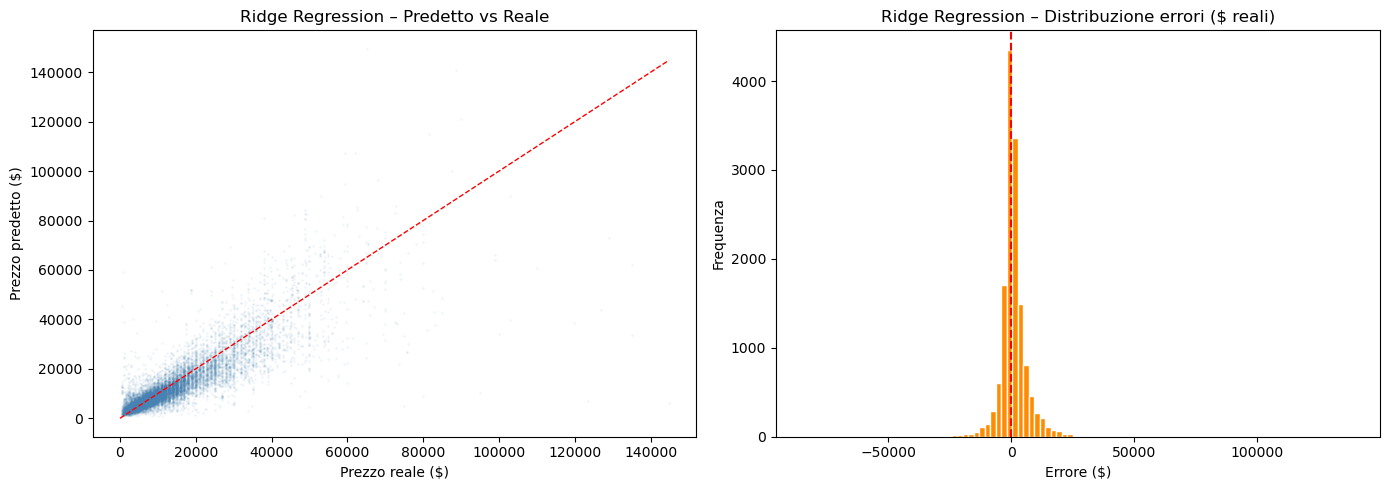

In [31]:
ridge_pipe = Pipeline([
    ('preproc', preprocessor),
    ('regr',    Ridge(alpha=1.0)),
])
ridge_pipe.fit(X_train_raw, y_train)

res = evaluate_pipeline(ridge_pipe, X_train_raw, X_test_raw, y_train, y_test, y_orig_test, 'Ridge')
results_list.append(res)
trained_models['Ridge'] = ridge_pipe
print(f"Ridge – R²: {res['R² (log)']:.3f} | RMSE: ${res['RMSE ($)']:,.0f} | MAE: ${res['MAE ($)']:,.0f}")
plot_predictions(ridge_pipe, X_test_raw, y_orig_test, 'Ridge Regression')

ridge_features = ridge_pipe[:-1].get_feature_names_out()
ridge_coef     = ridge_pipe.named_steps['regr'].coef_

In [32]:
cv5_ridge = cross_validate(ridge_pipe, X_raw, y, cv=k_fold_5, scoring='r2')
print(f"CV-5 Ridge – R² medio: {cv5_ridge['test_score'].mean():.3f} ± {cv5_ridge['test_score'].std():.3f}")

cv7_ridge = cross_validate(ridge_pipe, X_raw, y, cv=k_fold_7, scoring='r2')
print(f"CV-7 Ridge – R² medio: {cv7_ridge['test_score'].mean():.3f} ± {cv7_ridge['test_score'].std():.3f}")

CV-5 Ridge – R² medio: 0.723 ± 0.005
CV-7 Ridge – R² medio: 0.724 ± 0.005


### Ridge + PCA

In [33]:
ridge_pca_pipe = Pipeline([
    ('preproc', preprocessor),
    ('to_dense', FunctionTransformer(lambda x: x.toarray() if hasattr(x, "toarray") else x)),
    ('pca',     PCA(n_components=0.95, random_state=42)),
    ('regr',    Ridge(alpha=1.0)),
])
ridge_pca_pipe.fit(X_train_raw, y_train)

res_pca = evaluate_pipeline(ridge_pca_pipe, X_train_raw, X_test_raw, y_train, y_test, y_orig_test, 'Ridge (PCA)')
results_list.append(res_pca)
print(f"Ridge PCA – R²: {res_pca['R² (log)']:.3f} | RMSE: ${res_pca['RMSE ($)']:,.0f} | MAE: ${res_pca['MAE ($)']:,.0f}")

Ridge PCA – R²: 0.700 | RMSE: $6,704 | MAE: $3,845


## Modello di regressione LASSO

Il modello LASSO differisce da Ridge nella scelta della penalizzazione: al posto della norma L2, utilizza la norma L1 dei coefficienti. Questo ha l'effetto di azzerare completamente i coefficienti delle feature meno rilevanti, producendo implicitamente una selezione automatica delle feature.

Con un valore aggressivo di `alpha`, ci si aspetta quindi che alcune colonne vengano escluse dal modello: analizzare quali feature vengono azzerate può fornire indicazioni utili sulla loro rilevanza nella predizione del prezzo.

Lasso – R²: 0.681 | RMSE: $6,863 | MAE: $3,996


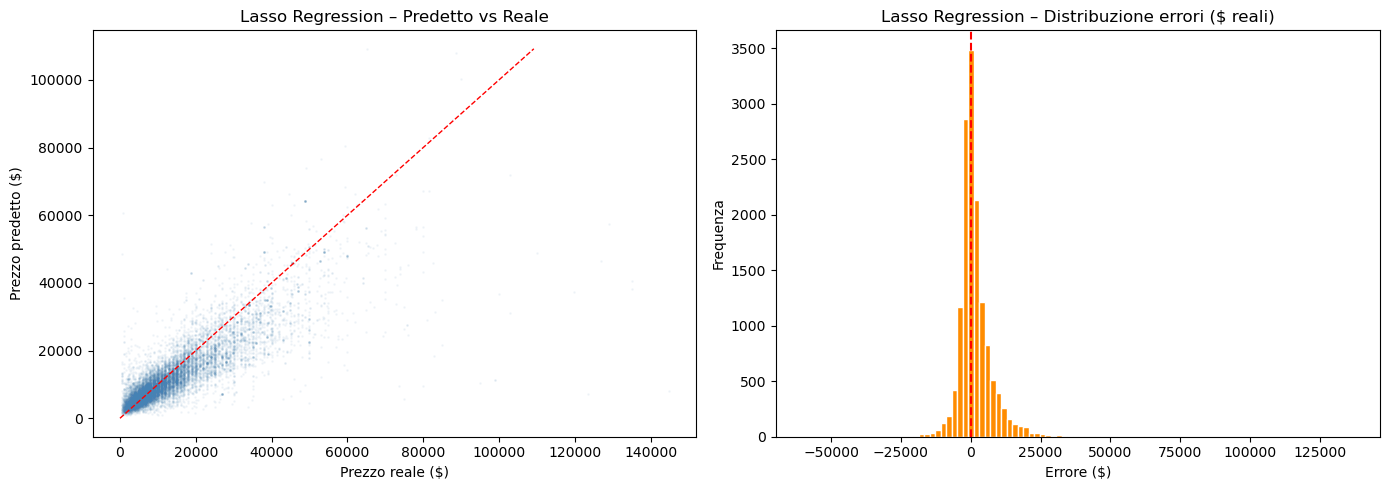

cat__fuel_gas                 3.876360e-01
num__year                     3.340153e-01
cat__drive_fwd                3.316193e-01
num__odometer                 2.605123e-01
cat__type_truck               2.541558e-01
cat__cylinders_8 cylinders    2.224645e-01
cat__type_sedan               1.841090e-01
cat__cylinders_4 cylinders    1.376682e-01
num__condition_encoded        1.184033e-01
cat__type_pickup              6.274626e-02
num__desc_len                 6.167904e-02
cat__manufacturer_toyota      5.407877e-02
num__long                     3.307609e-02
num__posting_month            1.355977e-02
num__desc_has_new_tires       1.177590e-03
num__car_age                  8.854344e-13
cat__state_mi                 0.000000e+00
cat__state_ma                 0.000000e+00
cat__state_me                 0.000000e+00
cat__state_md                 0.000000e+00
dtype: float64

In [34]:
lasso_pipe = Pipeline([
    ('preproc', preprocessor),
    ('regr',    Lasso(alpha=0.01, random_state=42)) 
])
lasso_pipe.fit(X_train_raw, y_train)

res = evaluate_pipeline(lasso_pipe, X_train_raw, X_test_raw, y_train, y_test, y_orig_test, 'Lasso')
results_list.append(res)
trained_models['Lasso'] = lasso_pipe
print(f"Lasso – R²: {res['R² (log)']:.3f} | RMSE: ${res['RMSE ($)']:,.0f} | MAE: ${res['MAE ($)']:,.0f}")
plot_predictions(lasso_pipe, X_test_raw, y_orig_test, 'Lasso Regression')

# Analisi coefficienti 
lasso_features = lasso_pipe[:-1].get_feature_names_out()
lasso_coef     = lasso_pipe.named_steps['regr'].coef_
pd.Series(lasso_coef, index=lasso_features).abs().sort_values(ascending=False).head(20)

In [35]:
cv5_lasso = cross_validate(lasso_pipe, X_raw, y, cv=k_fold_5, scoring='r2')
print(f"CV-5 Lasso – R² medio: {cv5_lasso['test_score'].mean():.3f} ± {cv5_lasso['test_score'].std():.3f}")

cv7_lasso = cross_validate(lasso_pipe, X_raw, y, cv=k_fold_7, scoring='r2')
print(f"CV-7 Lasso – R² medio: {cv7_lasso['test_score'].mean():.3f} ± {cv7_lasso['test_score'].std():.3f}")

CV-5 Lasso – R² medio: 0.675 ± 0.005
CV-7 Lasso – R² medio: 0.675 ± 0.005


### Lasso + PCA

In [36]:
lasso_pca_pipe = Pipeline([
    ('preproc', preprocessor),
    ('to_dense', FunctionTransformer(lambda x: x.toarray() if hasattr(x, "toarray") else x)),
    ('pca',     PCA(n_components=0.95, random_state=42)),
    ('regr',    Lasso(alpha=0.01, random_state=42)),
])
lasso_pca_pipe.fit(X_train_raw, y_train)

res_pca = evaluate_pipeline(lasso_pca_pipe, X_train_raw, X_test_raw, y_train, y_test, y_orig_test, 'Lasso (PCA)')
results_list.append(res_pca)
print(f"Lasso PCA – R²: {res_pca['R² (log)']:.3f} | RMSE: ${res_pca['RMSE ($)']:,.0f} | MAE: ${res_pca['MAE ($)']:,.0f}")

Lasso PCA – R²: 0.677 | RMSE: $7,005 | MAE: $4,076


# Ricerca degli iperparametri ottimi

Fino a questo punto i modelli sono stati valutati con iperparametri fissati empiricamente. Per trovare la configurazione ottimale in modo sistematico, si applica la tecnica della **Grid Search**: viene definita una griglia di possibili valori per ciascun iperparametro, e ogni combinazione viene valutata tramite cross-validation.

La Grid Search viene applicata ai modelli Ridge, Lasso, Decision Tree e RandomForest esplorando diversi valori di `alpha`, la presenza o assenza di `StandardScaler` e l'uso o meno di feature polinomiali.

In [37]:
from sklearn.model_selection import GridSearchCV
from sklearnex import unpatch_sklearn
unpatch_sklearn()


#### Ridge

In [38]:
ridge_gs_pipe = Pipeline([
    ('preproc', preprocessor),
    ('regr', Ridge()),
])

param_grid_ridge = {
    'regr__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
}

gs_ridge = GridSearchCV(ridge_gs_pipe, param_grid_ridge, 
                        cv=k_fold_5, scoring='r2', n_jobs=1)
gs_ridge.fit(X_train_raw, y_train)

print(f"Ridge – alpha ottimo: {gs_ridge.best_params_['regr__alpha']}")
print(f"Ridge – R² migliore (CV): {gs_ridge.best_score_:.3f}")

# Salva il modello ottimo e valutalo
res_gs_ridge = evaluate_pipeline(gs_ridge.best_estimator_, X_train_raw, X_test_raw, 
                                  y_train, y_test, y_orig_test, 'Ridge (GridSearch)')
results_list.append(res_gs_ridge)
print(f"Ridge GS – R²: {res_gs_ridge['R² (log)']:.3f} | RMSE: ${res_gs_ridge['RMSE ($)']:,.0f} | MAE: ${res_gs_ridge['MAE ($)']:,.0f}")


Ridge – alpha ottimo: 1.0
Ridge – R² migliore (CV): 0.723
Ridge GS – R²: 0.723 | RMSE: $6,442 | MAE: $3,634


#### Lasso

In [39]:
lasso_gs_pipe = Pipeline([
    ('preproc', preprocessor),
    ('regr', Lasso(random_state=42)),
])
param_grid_lasso = {
    'regr__alpha': [0.001, 0.01, 0.1, 1.0]
}
gs_lasso = GridSearchCV(lasso_gs_pipe, param_grid_lasso,
                        cv=k_fold_5, scoring='r2', n_jobs=1)
gs_lasso.fit(X_train_raw, y_train)
print(f"Lasso – alpha ottimo: {gs_lasso.best_params_['regr__alpha']}")
print(f"Lasso – R² migliore (CV): {gs_lasso.best_score_:.3f}")
res_gs_lasso = evaluate_pipeline(gs_lasso.best_estimator_, X_train_raw, X_test_raw,
                                  y_train, y_test, y_orig_test, 'Lasso (GridSearch)')
results_list.append(res_gs_lasso)
print(f"Lasso GS – R²: {res_gs_lasso['R² (log)']:.3f} | RMSE: ${res_gs_lasso['RMSE ($)']:,.0f} | MAE: ${res_gs_lasso['MAE ($)']:,.0f}")

Lasso – alpha ottimo: 0.001
Lasso – R² migliore (CV): 0.711
Lasso GS – R²: 0.714 | RMSE: $6,579 | MAE: $3,713


#### Decision Tree

In [40]:
dt_gs_pipe = Pipeline([
    ('preproc', preprocessor),
    ('regr', DecisionTreeRegressor(random_state=42)),
])
param_grid_dt = {
    'regr__max_depth': [4, 6, 8, 10],
    'regr__min_samples_split': [10, 50, 100]
}
gs_dt = GridSearchCV(dt_gs_pipe, param_grid_dt,
                     cv=k_fold_5, scoring='r2', n_jobs=1)
gs_dt.fit(X_train_raw, y_train)
print(f"DT – parametri ottimi: {gs_dt.best_params_}")
print(f"DT – R² migliore (CV): {gs_dt.best_score_:.3f}")
res_gs_dt = evaluate_pipeline(gs_dt.best_estimator_, X_train_raw, X_test_raw, y_train, y_test, y_orig_test, 'Decision Tree (GridSearch)')
results_list.append(res_gs_dt)
print(f"DT GS – R²: {res_gs_dt['R² (log)']:.3f} | RMSE: ${res_gs_dt['RMSE ($)']:,.0f} | MAE: ${res_gs_dt['MAE ($)']:,.0f}")

DT – parametri ottimi: {'regr__max_depth': 10, 'regr__min_samples_split': 10}
DT – R² migliore (CV): 0.728
DT GS – R²: 0.742 | RMSE: $5,941 | MAE: $3,399


#### Random Forest

In [41]:
from sklearnex import unpatch_sklearn
unpatch_sklearn()
from sklearn.model_selection import RandomizedSearchCV

rf_gs_pipe = Pipeline([
    ('preproc', preprocessor),
    ('regr', RandomForestRegressor(random_state=42, n_jobs=1)),
])

param_grid_rf = {
    'regr__n_estimators': [10, 30],
    'regr__max_depth': [5, 10],
}


gs_rf = RandomizedSearchCV(rf_gs_pipe, param_grid_rf,
                            n_iter=4, cv=3, scoring='r2',
                            random_state=42, n_jobs=-1)
gs_rf.fit(X_train_raw, y_train)

print(f"RF – parametri ottimi: {gs_rf.best_params_}")
print(f"RF – R² migliore (CV): {gs_rf.best_score_:.3f}")

res_gs_rf = evaluate_pipeline(gs_rf.best_estimator_, X_train_raw, X_test_raw, y_train, y_test, y_orig_test, 'Random Forest (GridSearch)')
results_list.append(res_gs_rf)
print(f"RF GS – R²: {res_gs_rf['R² (log)']:.3f} | RMSE: ${res_gs_rf['RMSE ($)']:,.0f} | MAE: ${res_gs_rf['MAE ($)']:,.0f}")

RF – parametri ottimi: {'regr__n_estimators': 30, 'regr__max_depth': 10}
RF – R² migliore (CV): 0.773
RF GS – R²: 0.782 | RMSE: $5,599 | MAE: $3,150


# Regressione basata su alberi decisionali

I modelli di regressione lineare, anche con feature polinomiali, faticano a catturare relazioni non lineari complesse. Un `DecisionTreeRegressor` supera questo limite costruendo una struttura ad albero che partiziona ricorsivamente lo spazio delle feature in regioni omogenee, assegnando a ciascuna un valore predetto costante.

Rispetto ai modelli lineari, gli alberi permettono inoltre di stimare direttamente l'**importanza delle feature**, analizzando quante volte e con quale guadagno informativo ciascuna viene usata come criterio di split lungo l'albero.

Gli iperparametri principali da ottimizzare sono `max_depth` (profondità massima dell'albero, che controlla la complessità del modello) e `min_samples_split` (numero minimo di campioni richiesto per effettuare uno split, che limita l'overfitting).

Decision Tree – R²: 0.676 | RMSE: $6,942 | MAE: $4,146


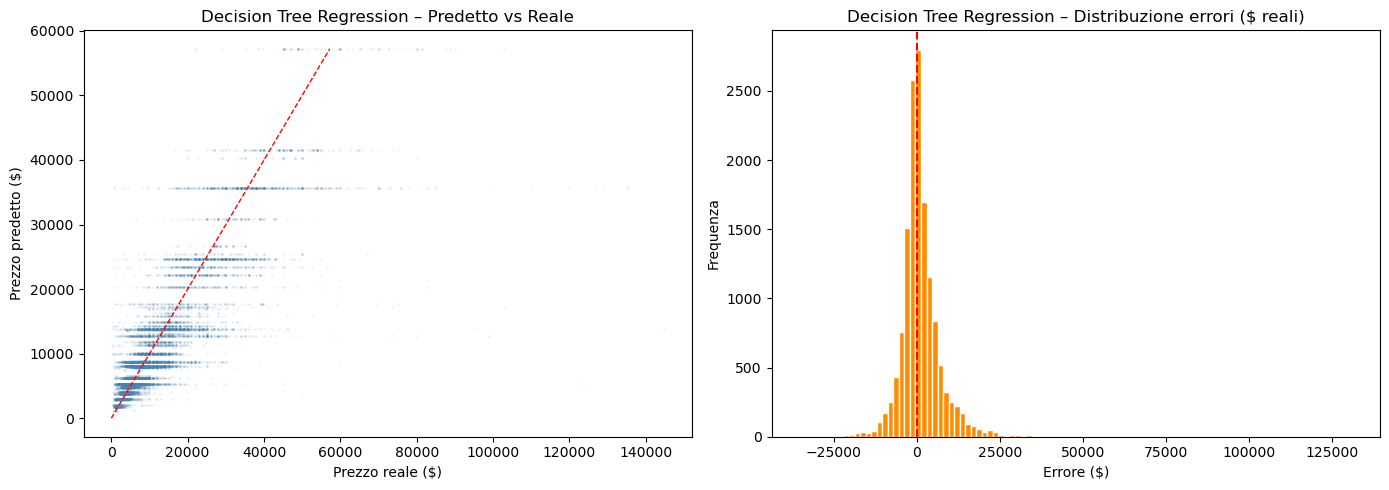

CV-5 DT – R² medio: 0.665 ± 0.007


In [42]:
dt_pipe = Pipeline([
    ('preproc', preprocessor),
    ('regr',    DecisionTreeRegressor(max_depth=6, random_state=42)),
])

dt_pipe.fit(X_train_raw, y_train)

res = evaluate_pipeline(dt_pipe, X_train_raw, X_test_raw, y_train, y_test, y_orig_test, 'Decision Tree')
results_list.append(res)
trained_models['DecisionTree'] = dt_pipe
print(f"Decision Tree – R²: {res['R² (log)']:.3f} | RMSE: ${res['RMSE ($)']:,.0f} | MAE: ${res['MAE ($)']:,.0f}")
plot_predictions(dt_pipe, X_test_raw, y_orig_test, 'Decision Tree Regression')

cv5_dt = cross_validate(dt_pipe, X_raw, y, cv=k_fold_5, scoring='r2',n_jobs=-1)
print(f"CV-5 DT – R² medio: {cv5_dt['test_score'].mean():.3f} ± {cv5_dt['test_score'].std():.3f}")

# Foreste di regressione

Una singola Random Forest estende il concetto di albero decisionale addestrando un insieme (`ensemble`) di alberi su sottocampioni casuali del dataset e delle feature (*bagging*). La predizione finale è la media delle predizioni dei singoli alberi, il che riduce la varianza del modello rispetto a un singolo albero e migliora la generalizzazione.

Il principale iperparametro da regolare è `n_estimators` (numero di alberi): un numero maggiore migliora la stabilità della predizione a scapito del tempo di addestramento. Si usa `n_jobs=-1` per parallelizzare il training su tutti i core disponibili.

RF – R²: 0.700 | RMSE: $6,753 | MAE: $3,951


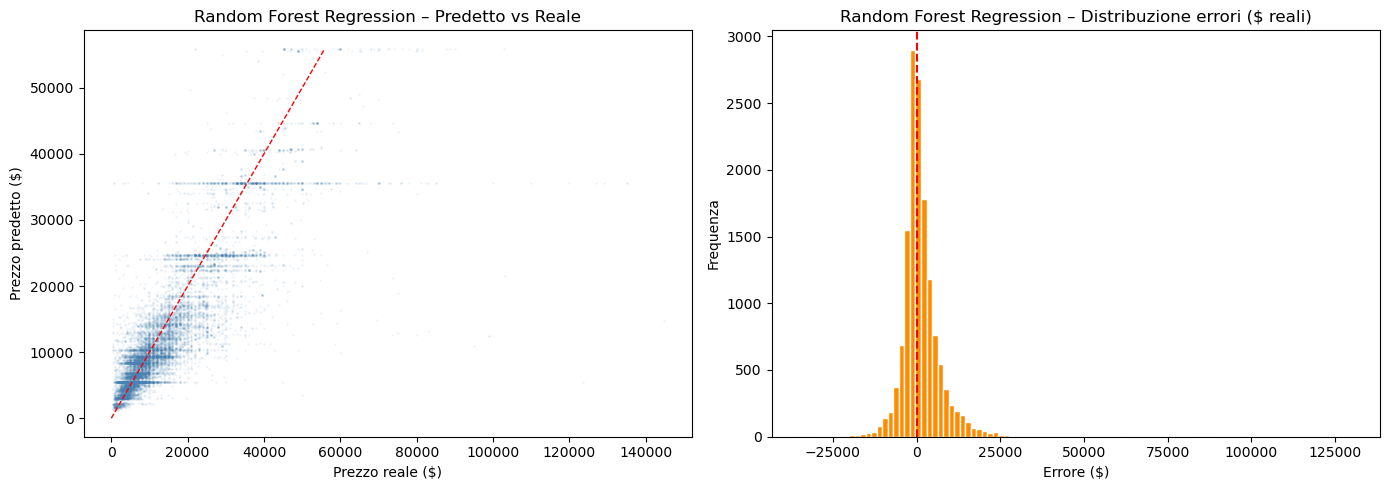

CV-5 RF – R² medio: 0.689 ± 0.008


In [44]:
from sklearnex import unpatch_sklearn
unpatch_sklearn()

rf_pipe = Pipeline([
    ('preproc', preprocessor),
    ('regr',    RandomForestRegressor(n_estimators=50, max_depth=6, random_state=42, n_jobs=-1)),
])
rf_pipe.fit(X_train_raw, y_train)

res = evaluate_pipeline(rf_pipe, X_train_raw, X_test_raw, y_train, y_test, y_orig_test, 'Random Forest')
results_list.append(res)
trained_models['RandomForest'] = rf_pipe
print(f"RF – R²: {res['R² (log)']:.3f} | RMSE: ${res['RMSE ($)']:,.0f} | MAE: ${res['MAE ($)']:,.0f}")
plot_predictions(rf_pipe, X_test_raw, y_orig_test, 'Random Forest Regression')


cv5_rf = cross_validate(rf_pipe, X_raw, y, cv=k_fold_5, scoring='r2')
print(f"CV-5 RF – R² medio: {cv5_rf['test_score'].mean():.3f} ± {cv5_rf['test_score'].std():.3f}")


# XGBoost

I modelli testati finora usano due approcci: modelli lineari e alberi con *bagging* (Random Forest).

Viene ora introdotto **XGBoost** (*Extreme Gradient Boosting*), che adotta una strategia diversa: il **gradient boosting**.

Invece di addestrare gli alberi in parallelo e calcolarne la media (come fa Random Forest),
XGBoost li addestra **in sequenza**: ogni albero impara a correggere gli errori di quelli precedenti,
riducendo iterativamente l'errore residuo. 

La predizione finale è la somma dei contributi di tutti gli alberi.

Questo approccio lo rende particolarmente efficace su dataset tabulari con feature miste,
rendendolo un candidato naturale per migliorare ulteriormente le performance del miglior modello ottenuto finora.

I principali iperparametri utilizzati sono:
- `n_estimators`: numero di alberi
- `learning_rate`: peso del contributo di ogni albero (valori bassi riducono il rischio di overfitting)
- `max_depth`: profondità massima di ogni albero

XGB – R²: 0.843 | RMSE: $4,841 | MAE: $2,588


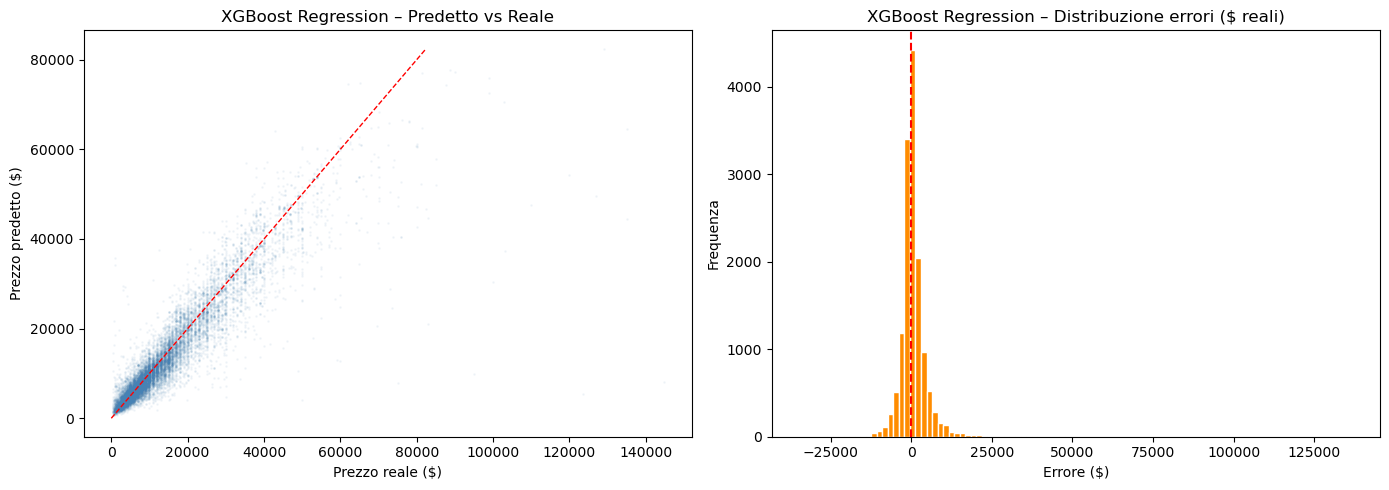

CV-5 XGB – R² medio: 0.842 ± 0.003


In [46]:
from xgboost import XGBRegressor

xgb_pipe = Pipeline([
    ('preproc', preprocessor),
    ('regr', XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])

xgb_pipe.fit(X_train_raw, y_train)

res = evaluate_pipeline(xgb_pipe, X_train_raw, X_test_raw, y_train, y_test, y_orig_test, 'XGBoost')
results_list.append(res)
trained_models['XGBoost'] = xgb_pipe
print(f"XGB – R²: {res['R² (log)']:.3f} | RMSE: ${res['RMSE ($)']:,.0f} | MAE: ${res['MAE ($)']:,.0f}")
plot_predictions(xgb_pipe, X_test_raw, y_orig_test, 'XGBoost Regression')

cv5_xgb = cross_validate(xgb_pipe, X_raw, y, cv=k_fold_5, scoring='r2')
print(f"CV-5 XGB – R² medio: {cv5_xgb['test_score'].mean():.3f} ± {cv5_xgb['test_score'].std():.3f}")

## Confronto Feature Importance: XGBoost vs Random Forest

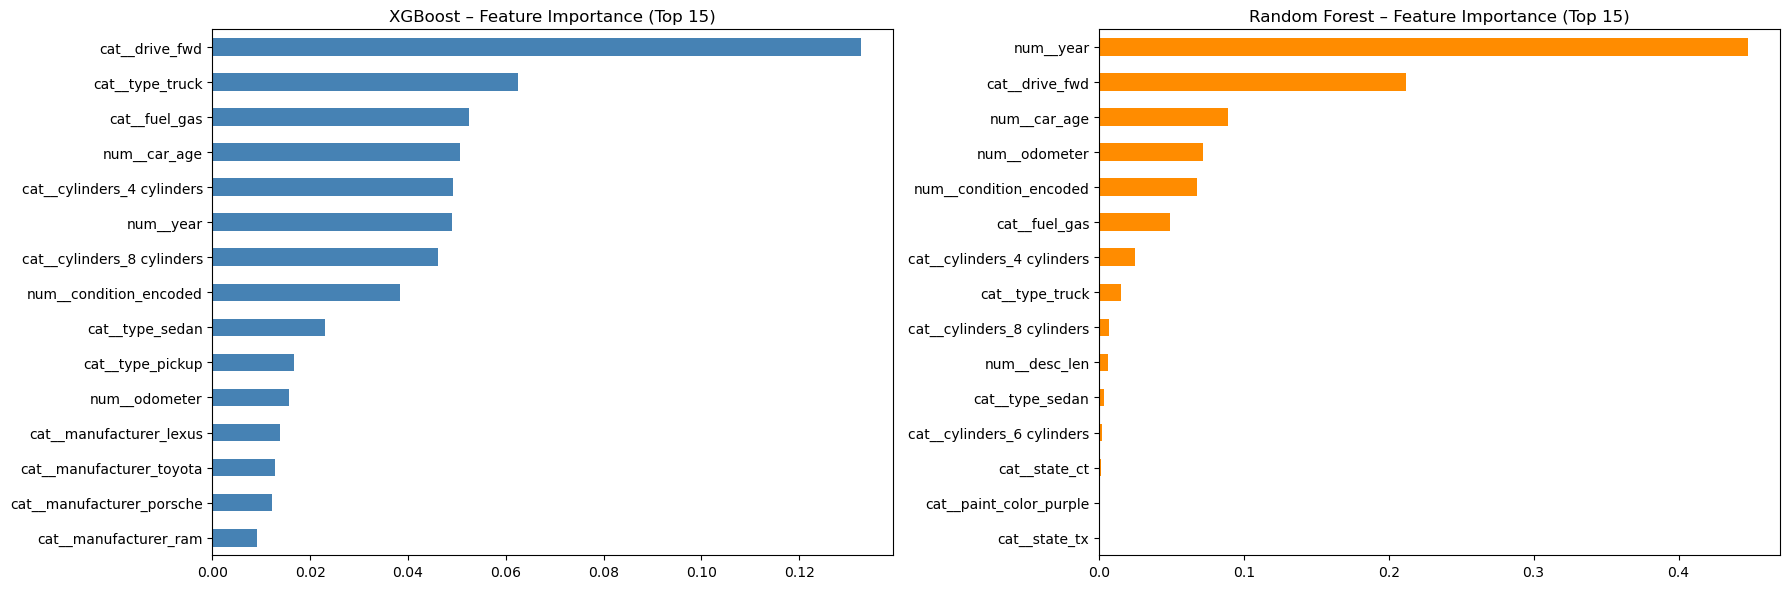

In [49]:
xgb_model = xgb_pipe.named_steps['regr']
feature_names = xgb_pipe.named_steps['preproc'].get_feature_names_out()

importances_xgb = pd.Series(xgb_model.feature_importances_, index=feature_names).sort_values(ascending=False).head(15)

rf_model = rf_pipe.named_steps['regr']
importances_rf = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

importances_xgb.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('XGBoost – Feature Importance (Top 15)')
axes[0].invert_yaxis()

importances_rf.plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Random Forest – Feature Importance (Top 15)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

I due modelli mostrano approcci diversi nell'identificare le variabili più rilevanti:

- Il **Random Forest** concentra il peso su poche variabili dominanti: `year` da sola  rappresenta quasi il 50% dell'importanza totale, seguita da `drive_fwd` e `car_age`.  Le variabili categoriali come marca e tipo di veicolo hanno un peso marginale.

- **XGBoost** invece distribuisce l'importanza in modo più equilibrato tra le feature:  `drive_fwd` risulta la variabile più importante, ma il peso è ripartito su molte  variabili come il tipo di veicolo (`truck`, `sedan`, `pickup`), carburante, numero di  cilindri, condizione e persino la marca (`lexus`, `toyota`, `porsche`, `ram`).  Questo suggerisce che XGBoost riesce a sfruttare meglio le variabili categoriali,  estraendo informazioni utili anche da feature che il Random Forest tendeva a ignorare.

Questa maggiore capacità di valorizzare l'intero insieme di feature contribuisce 
a spiegare il miglioramento nelle metriche finali (R² da 0.782 a 0.843).

# Confronto fra tutti i modelli

In [47]:
df_results = pd.DataFrame(results_list).sort_values('R² (log)', ascending=False).reset_index(drop=True)
df_results = df_results.round({'R² (log)': 3, 'RMSE ($)': 0, 'MAE ($)': 0, 'MAPE (%)': 2})
display(df_results)

,Model,R² (log),RMSE ($),MAE ($),MAPE (%)
0,XGBoost,0.843,4841.0,2588.0,26.80
1,Random Forest (GridSearch),0.782,5599.0,3150.0,33.65
2,Decision Tree (GridSearch),0.742,5941.0,3399.0,36.55
3,Ridge,0.723,6442.0,3634.0,39.69
4,Ridge (GridSearch),0.723,6442.0,3634.0,39.69
5,Linear Regression,0.723,6435.0,3632.0,39.69
6,Lasso (GridSearch),0.714,6579.0,3713.0,40.76
7,Ridge (PCA),0.700,6704.0,3845.0,42.28
8,Linear Regression (PCA),0.700,6704.0,3846.0,42.28
9,Random Forest,0.700,6753.0,3951.0,42.40


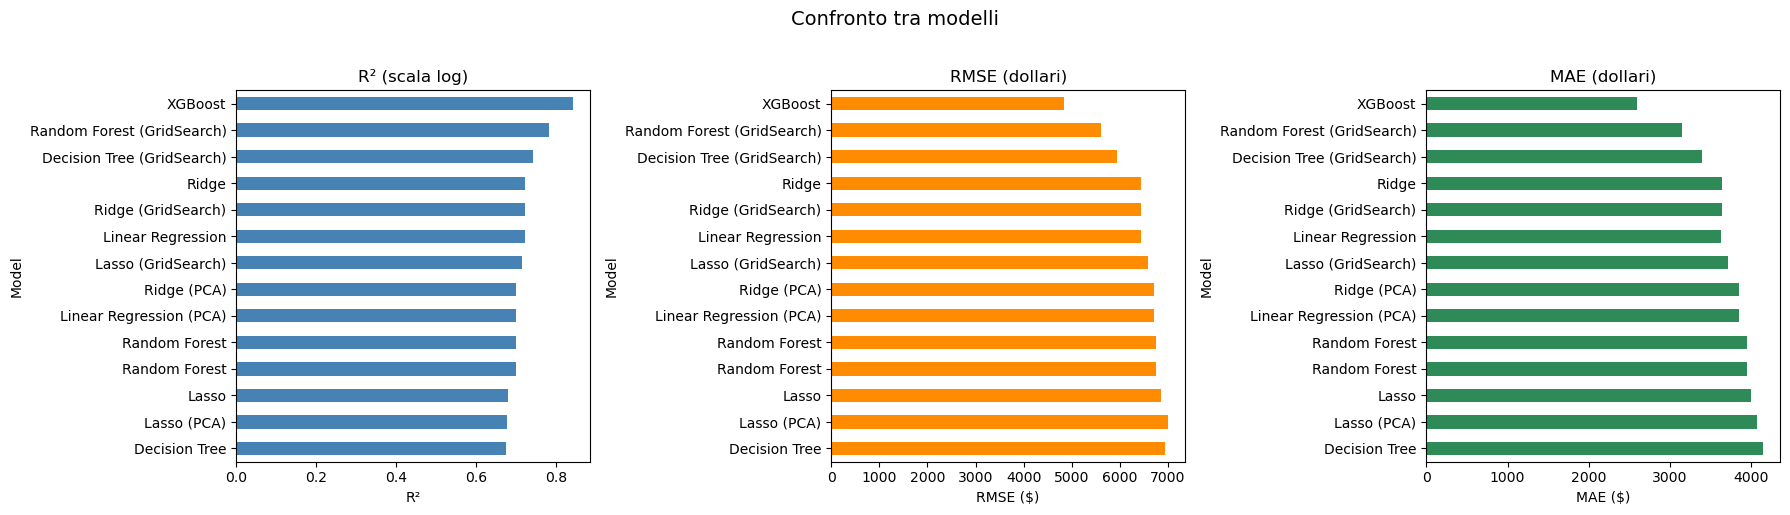

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df_results.plot(kind='barh', x='Model', y='R² (log)', ax=axes[0], 
                color='steelblue', legend=False)
axes[0].set_title('R² (scala log)')
axes[0].set_xlabel('R²')
axes[0].invert_yaxis()

df_results.plot(kind='barh', x='Model', y='RMSE ($)', ax=axes[1],
                color='darkorange', legend=False)
axes[1].set_title('RMSE (dollari)')
axes[1].set_xlabel('RMSE ($)')
axes[1].invert_yaxis()

df_results.plot(kind='barh', x='Model', y='MAE ($)', ax=axes[2],
                color='seagreen', legend=False)
axes[2].set_title('MAE (dollari)')
axes[2].set_xlabel('MAE ($)')
axes[2].invert_yaxis()

plt.suptitle('Confronto tra modelli', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Analisi comparativa: con e senza PCA
La PCA (Principal Component Analysis) è stata applicata come tecnica di riduzione della dimensionalità in combinazione con i modelli lineari (Ridge, Linear Regression e Lasso).

L'obiettivo era di verificare se comprimere le feature in componenti principali portasse benefici in termini di accuratezza o generalizzazione.

### Risultati a confronto

| Modello | R² (log) | RMSE ($) | SS | MAPE (%) |
|:---|:---:|:---:|:---:|:---:|
| Ridge (full features) | 0.723 | 6442 | 3634 | 39.69 |
| Ridge (PCA) | 0.700 | 6704 | 3845 | 42.28 |
| Linear Regression (full features) | 0.723 | 6435 | 3632 | 39.69 |
| Linear Regression (PCA) | 0.700 | 6704 | 3846 | 42.28 |
| Lasso | 0.681 | 6863 | 3996 | 44.09 |
| Lasso (PCA) | 0.677 | 7005 | 4076 | 44.29 |

### Osservazioni

In tutti i casi analizzati, l'applicazione della PCA ha prodotto un **peggioramento delle performance**
rispetto ai modelli addestrati sulle feature complete:

- Ridge: R² scende da 0.723 a 0.700 (+2.3 punti percentuali di MAPE)
- Linear Regression: risultati identici a Ridge, stessa degradazione
- Lasso: la versione con PCA riduce ulteriormente R²

### Perché la PCA non aiuta in questo contesto?

La PCA è particolarmente efficace quando:
- le feature originali sono fortemente correlate tra loro (multicollinearità elevata),
- il numero di feature è molto alto rispetto ai campioni (curse of dimensionality),
- si vuole ridurre il rumore comprimendo la varianza in poche componenti.

In questo dataset, tuttavia, gran parte delle feature sono **categoriali codificate tramite One-Hot Encoding**
(marca, tipo di veicolo, stato, condizione, ecc.). Ogni colonna OHE rappresenta un'informazione
discreta e specifica — ad esempio, distinguere "ford" da "toyota" ha un impatto diretto e interpretabile
sul prezzo. La PCA aggrega queste colonne in componenti che mescolano categorie diverse,
**perdendo questa specificità senza ridurre realmente il rumore**.

Inoltre, le feature numeriche chiave (`year`, `odometer`) sono già poche e ben definite:
non c'è una dimensionalità eccessiva da comprimere.

### Resoconto

La PCA **non è la tecnica più adatta** per questo tipo di problema.
Il suo utilizzo introduce una perdita di informazione che si traduce in una riduzione misurabile
dell'accuratezza predittiva. I modelli addestrati sulle feature originali complete si dimostrano
superiori in ogni metrica considerata.La comparazione è comunque utile dal punto di vista metodologico: conferma che la scelta
delle tecniche di preprocessing deve essere guidata dalla natura dei dati, e non applicata
indiscriminatamente.

## Conclusioni Finali

L'obiettivo del progetto era costruire un modello in grado di stimare il prezzo di un'auto usata 
a partire dalle sue caratteristiche, così da rilevare se un annuncio è sopra o sotto il valore di mercato.

### Modello più efficace
Il modello **XGBoost** ha ottenuto le performance migliori:
- **R² = 0.843** sul test set (scala logaritmica)
- **RMSE = $4841.0** - errore quadratico medio in dollari
- **MAE = $2588.0** - errore assoluto medio in dollari
- **MAPE = 26.80%** - errore percentuale medio

XGBoost si è rivelato il modello più accurato grazie al suo approccio di gradient boosting: 
addestrando gli alberi in sequenza, ognuno corregge gli errori del precedente, riuscendo a 
catturare pattern complessi nei dati meglio di qualsiasi altro modello testato.

### Confronto generale
| Categoria | Risultato |
|---|---|
| Modelli lineari (LR, Ridge, Lasso) | R² ≈ 0.6–0.7, limitati da relazioni non lineari |
| Decision Tree | Buona capacità non lineare, ma soggetto a overfitting |
| Random Forest | Buona generalizzazione grazie all'ensemble, R² = 0.782 |
| **XGBoost** | **Migliore generalizzazione, R² = 0.843** |

### Osservazioni
- La trasformazione logaritmica del target ha migliorato significativamente le performance dei modelli lineari
- Le variabili più influenti variano tra i modelli: XGBoost distribuisce l'importanza 
  su `drive_fwd`, `type_truck`, `fuel_gas`, `car_age` e `cylinders_4`
  
  Mentre il Random Forest concentra quasi il 50% del peso su `year` da sola, seguito da `drive_fwd` 
  e `car_age`; entrambi i modelli concordano sull'importanza della trazione e dell'età del veicolo
- La cross-validation a 5 fold ha confermato la stabilità delle stime
- Il modello può essere utilizzato come riferimento per valutare se un annuncio è sopra o sotto il valore di mercato atteso

Il MAPE del modello migliore si attesta al 26.80%, miglioramento significativo rispetto al 33.65% 
del Random Forest. L'errore residuo è in parte spiegabile con la natura stessa del dataset Craigslist, 
che include annunci con prezzi anomali, descrizioni incomplete e forte variabilità geografica. 
Il modello è comunque utilizzabile come riferimento indicativo per valutare se un'auto è sopra 
o sotto il prezzo di mercato atteso.